## Summary Step 3: Visualizing and Analyzing Data

In this step, I created charts to find patterns and stories hidden in the data.

#### What I did: 

- I built a "Bonus Dashboard" with 4 charts in 1 figure to see the whole story.

- I analyzed the "Price Distribution" to see the most common prices for used cars.

- I checked "Price vs Mileage" to see how the price drops when mileage increases.

#### Key Findings:

- I used a "Heatmap" to see which features affect the price the most.

- I grouped years into groups to compare "Old", "Classic", and "Modern" cars easily.

#### Final result:

- Visual insights and a complete dashboard for the final report.

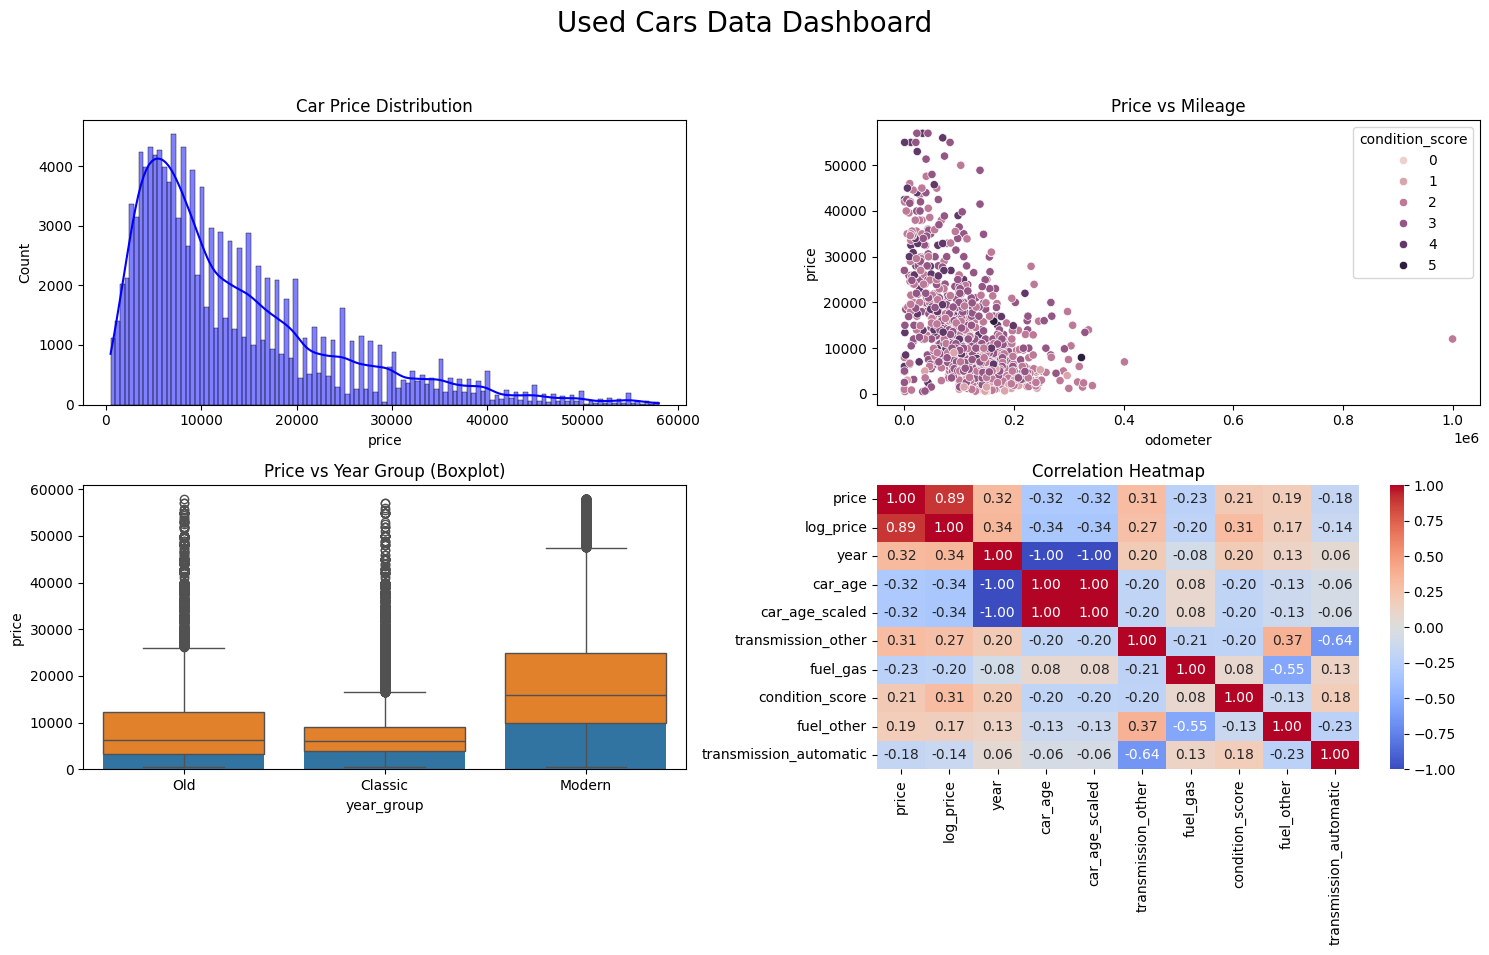


--- Average Price by Manufacturer ---
manufacturer
aston-martin    43565.833333
tesla           39283.181159
ferrari         34037.500000
alfa-romeo      26785.919118
porsche         24323.529670
rover           22531.696798
ram             22007.200219
audi            17697.471553
gmc             17529.099504
jaguar          16401.229958
Name: price, dtype: float64
manufacturer
aston-martin    43565.833333
tesla           39283.181159
ferrari         34037.500000
alfa-romeo      26785.919118
porsche         24323.529670
rover           22531.696798
ram             22007.200219
audi            17697.471553
gmc             17529.099504
jaguar          16401.229958
Name: price, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Features Data
df = pd.read_csv("data/cleaned/cars_features.csv")

df['year_group'] = pd.cut(df['year'], bins=[1900, 2000, 2010, 2026], labels=['Old', 'Classic', 'Modern'])

# Dashboard 4 Charts in 1 Figure 

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Used Cars Data Dashboard', fontsize=20)

# Price Distribution Histogram

sns.histplot(df['price'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Car Price Distribution')

# Price vs Odometer Scatter Plot

sns.scatterplot(data=df.sample(1000), x='odometer', y='price', hue='condition_score', ax=axes[0, 1])
axes[0, 1].set_title('Price vs Mileage')

# Average Price by Year Group Bar Plot

sns.barplot(data=df, x='year_group', y='price', ax=axes[1, 0])
axes[1, 0].set_title('Average Price by Year Group')

# Price Boxplot by Year Group 
sns.boxplot(data=df, x='year_group', y='price', ax=axes[1, 0])
axes[1, 0].set_title('Price vs Year Group (Boxplot)')

# Correlation Heatmap 

top_corr = df.select_dtypes(include=[np.number]).corr()['price'].abs().sort_values(ascending=False).head(10)
sns.heatmap(df[top_corr.index].corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1, 2-1]) # corrected index
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Summary
print("\n--- Average Price by Manufacturer ---")
print(df.groupby('manufacturer')['price'].mean().sort_values(ascending=False).head(10))
print(df.groupby('manufacturer')['price'].mean().sort_values(ascending=False).head(10))